In [65]:
import polars as pl
import pandas as pd
import pickle
import os, sys
import numpy as np

from scipy.spatial.distance import cosine, pdist
from sklearn.metrics import pairwise_distances

import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from network import knn_graph

import networkx as nx

In [3]:
disease_ot = pl.read_parquet("../data/disease/disease.parquet")
disease_ot.head(1)

id,code,name,description,dbXRefs,parents,exactSynonyms,relatedSynonyms,narrowSynonyms,broadSynonyms,obsoleteTerms,obsoleteXRefs,children,ancestors,therapeuticAreas,descendants,ontology,synonyms
str,str,str,str,list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],struct[3],struct[4]
"""DOID_0050890""","""http://purl.obolibrary.org/obo…","""synucleinopathy""","""A neurodegenerative disease th…","[""MEDGEN:1682194"", ""MESH:D000080874"", … ""UMLS:C5191670""]","[""EFO_0005772"", ""MONDO_0021179""]","[""alpha Synucleinopathies"", ""synucleinopathy""]","[""alpha synucleinopathies"", ""synucleinopathies""]",[],[],[],[],"[""EFO_0006792"", ""EFO_1001050""]","[""EFO_0005772"", ""MONDO_0021179"", … ""OTAR_0000020""]","[""EFO_0000618"", ""OTAR_0000020""]","[""EFO_0006792"", ""EFO_1001050"", … ""MONDO_0014835""]","{false,false,{""http://purl.obolibrary.org/obo/DOID_0050890"",""DOID_0050890""}}","{[""alpha Synucleinopathies"", ""synucleinopathy""],[""alpha synucleinopathies"", ""synucleinopathies""],[],[]}"


In [4]:
disease_ot.shape

(47030, 18)

In [5]:
disease_embeddings = pl.read_parquet("../output/id_value_embeddings.parquet")
disease_embeddings.head(1)

id,variable,value,embeddings
str,str,str,"array[f32, 768]"
"""DOID_0050890""","""name""","""synucleinopathy""","[-0.982104, 0.099318, … 0.4078]"


In [6]:
# filter disease for diseases with associations 

disease_ot = disease_ot.filter(pl.col("id").is_in(disease_embeddings['id'].unique().to_list()))
disease_ot.shape

(26288, 18)

In [7]:
(
    disease_ot
    .explode(pl.col("exactSynonyms"))
    .select(['id','name','exactSynonyms'])
    .unique(subset=['name','exactSynonyms'], keep='first', maintain_order=True) # remove where (name == synonym)
)

id,name,exactSynonyms
str,str,str
"""DOID_0050890""","""synucleinopathy""","""alpha Synucleinopathies"""
"""DOID_0050890""","""synucleinopathy""","""synucleinopathy"""
"""DOID_10113""","""trypanosomiasis""","""Trypanosoma caused disease or …"
"""DOID_10113""","""trypanosomiasis""","""Trypanosoma disease or disorde…"
"""DOID_10113""","""trypanosomiasis""","""Trypanosoma infectious disease"""
…,…,…
"""Orphanet_99947""","""Autosomal dominant Charcot-Mar…","""Charcot-Marie-Tooth neuropathy…"
"""Orphanet_99947""","""Autosomal dominant Charcot-Mar…","""HMSN IIA2"""
"""Orphanet_99947""","""Autosomal dominant Charcot-Mar…","""HMSN2A2"""


In [8]:
# synonyms embeddings:

embedding_map = dict(zip(disease_embeddings["value"].to_list(), disease_embeddings["embeddings"].to_list()))

In [9]:
disease_ot_synonyms = (
    disease_ot
    .explode(pl.col("exactSynonyms"))  # Explode synonyms into separate rows
    .select(['id', 'name', 'exactSynonyms'])  # Keep necessary columns
    .filter(pl.col("name") != pl.col("exactSynonyms"))  # Remove rows where name == synonym
    .unique(subset=['name', 'exactSynonyms'], keep='first', maintain_order=True)  # Remove duplicates
)

In [10]:
disease_ot_synonyms = (
    disease_ot_synonyms
    .with_columns(
        pl.struct('name','exactSynonyms')
        .map_elements(
            lambda x: cosine(embedding_map[x['name']],embedding_map[x['exactSynonyms']]),
            return_dtype=pl.Float64
        ).alias('cosine_dist')
    )
)

In [11]:
disease_ot_synonyms.head(4)

synonyms_distances = disease_ot_synonyms['cosine_dist'].to_list()

In [12]:
#all_cosine_distances = pdist(
#    disease_embeddings.unique('value')['embeddings'].to_numpy(),
#    metric='cosine'
#)

In [13]:
np.min(disease_ot_synonyms['cosine_dist'].to_list())

np.float64(0.0)

In [14]:
rng = np.random.default_rng(42)

random_distances = pdist(rng.choice(disease_embeddings["embeddings"], size=450, replace=False),
      metric='cosine')

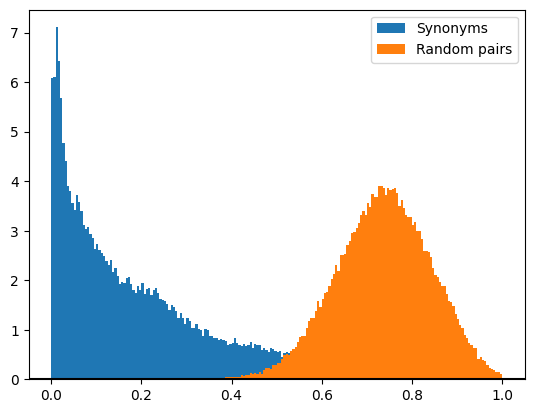

In [15]:
# Use a constant bin width to make the two histograms easier to compare visually
bin_width = 0.005
bins = np.arange(0,
                   1 + bin_width, bin_width)

fig, ax = plt.subplots()

# Plot the first histogram
ax.hist(synonyms_distances, bins=bins, label="Synonyms", density=True)

# Plot the second histogram
# (notice the negative weights, which flip the histogram upside down)
ax.hist(random_distances, weights=-np.ones_like(random_distances), bins=bins, label="Random pairs", density=True)
ax.axhline(0, color="k")
ax.legend()

plt.show()

In [16]:
#pdist_full = pairwise_distances(disease_embeddings['embeddings'].to_numpy())

In [18]:
disease_ot.head(1)

id,code,name,description,dbXRefs,parents,exactSynonyms,relatedSynonyms,narrowSynonyms,broadSynonyms,obsoleteTerms,obsoleteXRefs,children,ancestors,therapeuticAreas,descendants,ontology,synonyms
str,str,str,str,list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],struct[3],struct[4]
"""DOID_0050890""","""http://purl.obolibrary.org/obo…","""synucleinopathy""","""A neurodegenerative disease th…","[""MEDGEN:1682194"", ""MESH:D000080874"", … ""UMLS:C5191670""]","[""EFO_0005772"", ""MONDO_0021179""]","[""alpha Synucleinopathies"", ""synucleinopathy""]","[""alpha synucleinopathies"", ""synucleinopathies""]",[],[],[],[],"[""EFO_0006792"", ""EFO_1001050""]","[""EFO_0005772"", ""MONDO_0021179"", … ""OTAR_0000020""]","[""EFO_0000618"", ""OTAR_0000020""]","[""EFO_0006792"", ""EFO_1001050"", … ""MONDO_0014835""]","{false,false,{""http://purl.obolibrary.org/obo/DOID_0050890"",""DOID_0050890""}}","{[""alpha Synucleinopathies"", ""synucleinopathy""],[""alpha synucleinopathies"", ""synucleinopathies""],[],[]}"


In [24]:
len(set(embedding_map.keys()) & set(disease_ot['name']))

26288

In [25]:
len(set(disease_ot['name']))

26288

In [36]:
disease_ot_with_embeddings = (
    disease_ot
    .with_columns(
        pl.struct('id','name').map_elements(
            lambda t: embedding_map[t['name']],
            return_dtype=pl.Array(inner=pl.Float32, shape=768)
        ).alias("embeddings")
    )
)

In [46]:
knn_trait = knn_graph(X = disease_ot_with_embeddings['embeddings'].to_numpy())

Building graph...
Disconnected components: 75


In [48]:
p_distances = pairwise_distances(disease_ot_with_embeddings['embeddings'].to_numpy(), metric='cosine')

In [ ]:
# take the distribution of distances of the connected components

distances_knn = np.triu(p_distances * knn_trait).flatten()
distances_knn = distances_knn[distances_knn != 0]

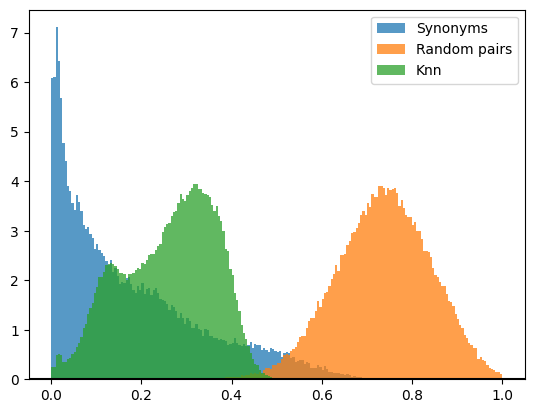

In [58]:
bin_width = 0.005
bins = np.arange(0,
                   1 + bin_width, bin_width)

fig, ax = plt.subplots()

# Plot the first histogram
ax.hist(synonyms_distances, bins=bins, label="Synonyms", density=True, alpha = 0.75)
ax.hist(random_distances, weights=-np.ones_like(random_distances), bins=bins, label="Random pairs", density=True,alpha = 0.75)
ax.hist(distances_knn, bins=bins, label="Knn", density=True, alpha = 0.75)

ax.axhline(0, color="k")
ax.legend()

plt.show()

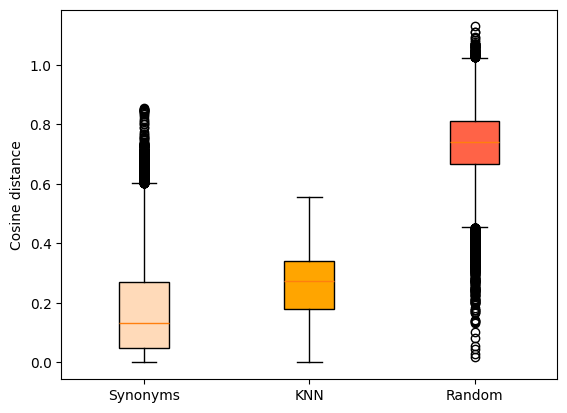

In [64]:

fig, ax = plt.subplots()

distributions = [
    synonyms_distances,
    distances_knn,
    random_distances,
]
labels = ['Synonyms', 'KNN', 'Random']
colors = ['peachpuff', 'orange', 'tomato']

ax.set_ylabel('Cosine distance')

bplot = ax.boxplot(distributions,
                   patch_artist=True,  # fill with color
                   tick_labels=labels)  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

In [68]:
trait_trait_network = nx.from_numpy_array(knn_trait, nodelist=disease_ot_with_embeddings['id'].to_list())

In [70]:
trait_trait_network.nodes

NodeView(('DOID_0050890', 'DOID_10113', 'DOID_10718', 'DOID_13406', 'DOID_1947', 'DOID_7551', 'GO_0000278', 'GO_0001503', 'GO_0001775', 'GO_0001806', 'GO_0002524', 'GO_0006006', 'GO_0006094', 'GO_0006096', 'GO_0006281', 'GO_0006412', 'GO_0006629', 'GO_0006694', 'GO_0006699', 'GO_0006810', 'GO_0006909', 'GO_0006915', 'GO_0006950', 'GO_0006954', 'GO_0006956', 'GO_0007420', 'GO_0007565', 'GO_0007585', 'GO_0007586', 'GO_0007596', 'GO_0007601', 'GO_0007605', 'GO_0007608', 'GO_0007610', 'GO_0007613', 'GO_0007623', 'GO_0008152', 'GO_0008283', 'GO_0009058', 'GO_0009314', 'GO_0009410', 'GO_0009415', 'GO_0009856', 'GO_0010226', 'GO_0014072', 'GO_0016068', 'GO_0019233', 'GO_0019395', 'GO_0019915', 'GO_0030073', 'GO_0030218', 'GO_0030431', 'GO_0030728', 'GO_0031424', 'GO_0031427', 'GO_0031960', 'GO_0032274', 'GO_0032502', 'GO_0033273', 'GO_0034097', 'GO_0035176', 'GO_0035456', 'GO_0035815', 'GO_0035882', 'GO_0036270', 'GO_0036273', 'GO_0036276', 'GO_0036277', 'GO_0040007', 'GO_0042060', 'GO_004247

In [72]:
nx.ego_graph(trait_trait_network, 'DOID_1947').nodes

NodeView(('EFO_0007523', 'DOID_1947', 'EFO_0007520', 'EFO_0007517', 'EFO_0007521', 'HP_0012167', 'EFO_0007516', 'HP_0001128', 'MONDO_0008593', 'MONDO_0013189', 'EFO_0007524'))